In [1]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

## Loading data

#### Mission data (for metrics for EQ2, EQ3, EQ4)

In [2]:

mission_data_df = pd.read_csv("../output/mission_data.csv")
mission_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,makespan,robot_id,robot_idle_time
0,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_1,68.891119
1,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_2,73.427535
2,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_3,77.964169
3,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_4,83.964793
4,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_5,94.502042
...,...,...,...,...,...,...,...,...,...
2443,test_5_10_t_agriculture_i2_bl2,5,10,2,agriculture,bl2,435.021733,robot_1,158.905609
2444,test_5_10_t_agriculture_i2_bl2,5,10,2,agriculture,bl2,435.021733,robot_2,386.944697
2445,test_5_10_t_agriculture_i2_bl2,5,10,2,agriculture,bl2,435.021733,robot_3,422.982018
2446,test_5_10_t_agriculture_i2_bl2,5,10,2,agriculture,bl2,435.021733,robot_4,421.501656


#### Execution data (for metrics for EQ1)

In [3]:
with open("../output/execution_check_results.json", 'r') as f:
    execution_data = json.load(f)

rows = []
for test_name, details in execution_data["mission_details"].items():
    labels = test_name.split("_")
    robot_count = int(labels[1])
    mission_size = int(labels[2])
    inv_id = int(labels[5][1])
    scenario = labels[4]
    mode = labels[6]
    row = {
        "test_id": test_name,
        "robot_count": robot_count,
        "mission_size": mission_size,
        "inventory_id": inv_id,
        "scenario": scenario,
        "mode": mode,
        "constrained_tasks": details["this_test_checks"],
        "respected_constraints": details["checks_passed"],
        "failed_constraints": details["checks_failed"],
        "test_result": details["test_ok"]
    }
    rows.append(row)

execution_data_df = pd.DataFrame(rows)
execution_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,constrained_tasks,respected_constraints,failed_constraints,test_result
0,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,12,12,0,True
1,test_5_20_t_surveillance_i1_multi3,5,20,1,surveillance,multi3,79,79,0,True
2,test_10_20_t_cleaning_i0_bl2,10,20,0,cleaning,bl2,40,40,0,True
3,test_10_20_t_surveillance_i2_bl0,10,20,2,surveillance,bl0,80,80,0,True
4,test_2_10_t_agriculture_i1_bl0,2,10,1,agriculture,bl0,43,43,0,True
...,...,...,...,...,...,...,...,...,...,...
427,test_5_20_t_logistics_i2_multi3,5,20,2,logistics,multi3,96,96,0,True
428,test_2_10_t_logistics_i2_bl2,2,10,2,logistics,bl2,45,45,0,True
429,test_2_20_t_cleaning_i0_bl0,2,20,0,cleaning,bl0,39,39,0,True
430,test_2_2_t_cleaning_i1_multi3,2,2,1,cleaning,multi3,4,4,0,True


## EQ1: Task order compliance

#### Metrics

Order satisfaction ratio:

$TOCR = \frac{1}{|\mathcal{O}|}\sum_{(t_i,t_j)\in\mathcal{O}} %\mathbf{1}_{end(t_i)\leq start(t_j)},
    \begin{cases}
    1 & \text{if  } end(t_i)\leq start(t_j) \\
    0 & \text{otherwise}
    \end{cases}
$

In [4]:
execution_data_df["tocr"] = execution_data_df["respected_constraints"] / execution_data_df["constrained_tasks"]
execution_data_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,constrained_tasks,respected_constraints,failed_constraints,test_result,tocr
0,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,12,12,0,True,1.0
1,test_5_20_t_surveillance_i1_multi3,5,20,1,surveillance,multi3,79,79,0,True,1.0
2,test_10_20_t_cleaning_i0_bl2,10,20,0,cleaning,bl2,40,40,0,True,1.0
3,test_10_20_t_surveillance_i2_bl0,10,20,2,surveillance,bl0,80,80,0,True,1.0
4,test_2_10_t_agriculture_i1_bl0,2,10,1,agriculture,bl0,43,43,0,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...
427,test_5_20_t_logistics_i2_multi3,5,20,2,logistics,multi3,96,96,0,True,1.0
428,test_2_10_t_logistics_i2_bl2,2,10,2,logistics,bl2,45,45,0,True,1.0
429,test_2_20_t_cleaning_i0_bl0,2,20,0,cleaning,bl0,39,39,0,True,1.0
430,test_2_2_t_cleaning_i1_multi3,2,2,1,cleaning,multi3,4,4,0,True,1.0


In [5]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_baseline = execution_data_df[execution_data_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_baseline_avg = (
    df_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "constrained_tasks": "mean",
        "respected_constraints": "mean",
        "failed_constraints": "mean",
        "tocr": "mean"
    })
)

df_baseline_avg["mode"] = "baseline"

df_multi3 = execution_data_df[execution_data_df["mode"] == "multi3"].copy()

df_grouped = pd.concat([df_baseline_avg, df_multi3], ignore_index=True)

df_grouped = df_grouped[group_cols + ["mode", "constrained_tasks", "respected_constraints", "failed_constraints", "tocr"]]
df_grouped

,scenario,robot_count,mission_size,inventory_id,mode,constrained_tasks,respected_constraints,failed_constraints,tocr
0,agriculture,2,2,0,baseline,11.000000,11.000000,0.0,1.0
1,agriculture,2,2,1,baseline,10.333333,10.333333,0.0,1.0
2,agriculture,2,2,2,baseline,11.000000,11.000000,0.0,1.0
3,agriculture,2,10,0,baseline,42.666667,42.666667,0.0,1.0
4,agriculture,2,10,1,baseline,43.000000,43.000000,0.0,1.0
...,...,...,...,...,...,...,...,...,...
211,surveillance,5,2,2,multi3,9.000000,9.000000,0.0,1.0
212,surveillance,2,2,0,multi3,9.000000,9.000000,0.0,1.0
213,cleaning,10,10,0,multi3,20.000000,20.000000,0.0,1.0
214,logistics,5,20,2,multi3,96.000000,96.000000,0.0,1.0


In [6]:
pivot_df = df_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["constrained_tasks", "respected_constraints", "failed_constraints", "tocr"]
)

pivot_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_df.columns]

pivot_df = pivot_df.reset_index()
pivot_df

,scenario,robot_count,mission_size,inventory_id,constrained_tasks_baseline,constrained_tasks_multi3,failed_constraints_baseline,failed_constraints_multi3,respected_constraints_baseline,respected_constraints_multi3,tocr_baseline,tocr_multi3
0,agriculture,2,2,0,11.000000,11.0,0.0,0.0,11.000000,11.0,1.0,1.0
1,agriculture,2,2,1,10.333333,10.0,0.0,0.0,10.333333,10.0,1.0,1.0
2,agriculture,2,2,2,11.000000,11.0,0.0,0.0,11.000000,11.0,1.0,1.0
3,agriculture,2,10,0,42.666667,41.0,0.0,0.0,42.666667,41.0,1.0,1.0
4,agriculture,2,10,1,43.000000,40.0,0.0,0.0,43.000000,40.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
103,surveillance,10,10,1,40.000000,40.0,0.0,0.0,40.000000,40.0,1.0,1.0
104,surveillance,10,10,2,39.333333,40.0,0.0,0.0,39.333333,40.0,1.0,1.0
105,surveillance,10,20,0,79.000000,73.0,0.0,0.0,79.000000,73.0,1.0,1.0
106,surveillance,10,20,1,79.333333,74.0,0.0,0.0,79.333333,74.0,1.0,1.0


In [7]:
df_avg = (
    pivot_df
    .groupby("scenario", as_index=False)
    .agg({
        "tocr_baseline": "mean",
        "tocr_multi3": "mean",
    })
)

df_avg["tocr_diff_percentage"] = ((df_avg["tocr_multi3"] - df_avg["tocr_baseline"]) / df_avg["tocr_baseline"]) *100

df_avg

,scenario,tocr_baseline,tocr_multi3,tocr_diff_percentage
0,agriculture,1.0,1.0,0.0
1,cleaning,1.0,1.0,0.0
2,logistics,1.0,1.0,0.0
3,surveillance,1.0,1.0,0.0


## EQ2: Mission completion time analysis

#### Data report

In [8]:
df_mission = (
    mission_data_df.groupby("test_id")
      .agg({
          "robot_count": "first",
          "mission_size": "first",
          "inventory_id": "first",
          "scenario": "first",
          "mode": "first",
          "makespan": "first",
          "robot_idle_time": "mean"
      })
      .reset_index()
)

df_mission.rename(columns={"robot_idle_time": "average_robot_idle_time"}, inplace=True)
df_mission = df_mission[["scenario", "robot_count", "mission_size", "inventory_id", "mode", "makespan", "average_robot_idle_time"]]

df_mission

,scenario,robot_count,mission_size,inventory_id,mode,makespan,average_robot_idle_time
0,agriculture,10,10,0,bl0,460.502100,412.860015
1,agriculture,10,10,0,bl1,462.041140,414.697298
2,agriculture,10,10,0,bl2,462.016871,414.674971
3,agriculture,10,10,0,multi3,186.040768,131.995788
4,agriculture,10,10,1,bl0,417.039088,375.242623
...,...,...,...,...,...,...,...
427,surveillance,5,2,1,multi3,88.501911,63.294573
428,surveillance,5,2,2,bl0,97.502152,78.278244
429,surveillance,5,2,2,bl1,94.502033,73.781911
430,surveillance,5,2,2,bl2,94.502032,75.286263


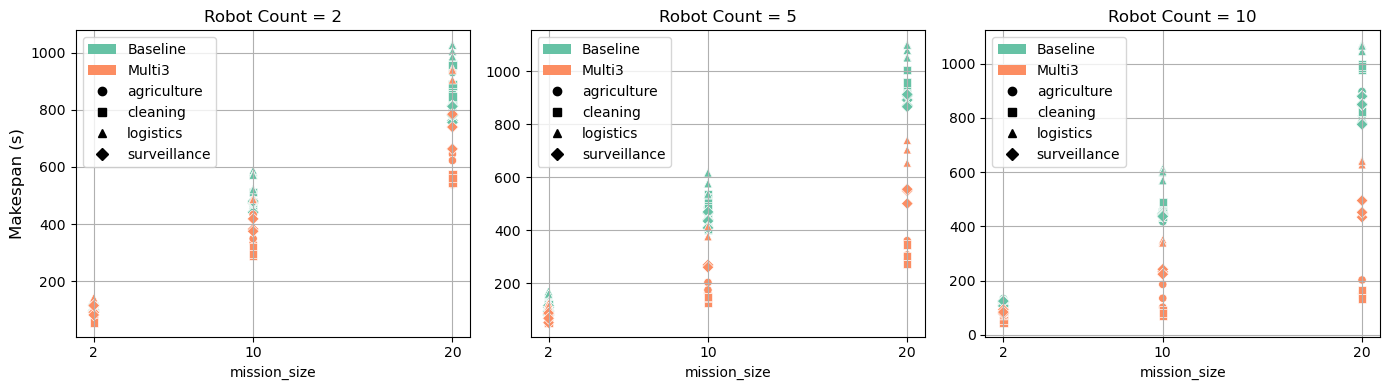

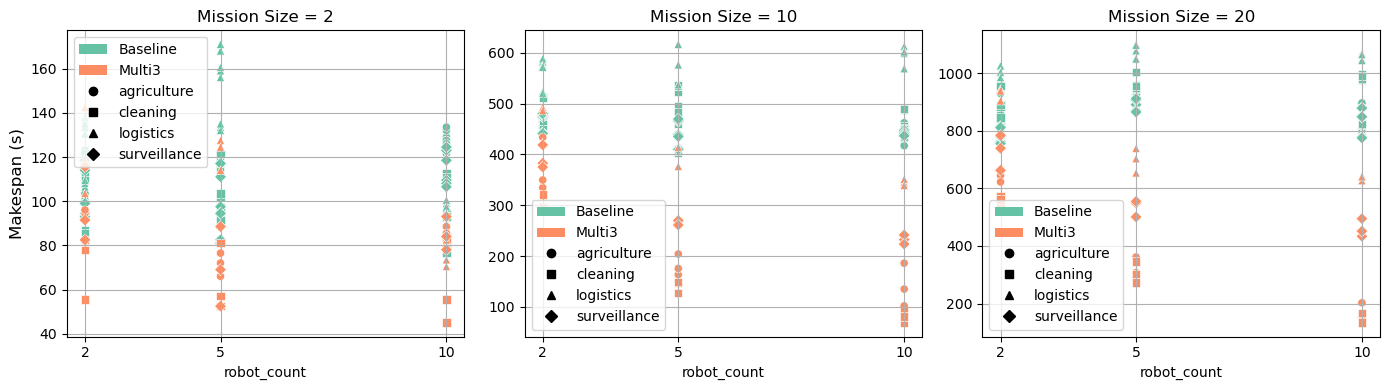

In [9]:
def multiplot(df,fname,external_variable,var_x,var_y,title,x_label,y_label):
    marker_dict = {
        'agriculture': 'o',
        'cleaning': 's',
        'logistics': '^',
        'surveillance': 'D',
        'other': 'v'
    }
    palette = sns.color_palette("Set2")
    approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for i, v in enumerate(external_variable_values):
        x_df = df[(df[external_variable] == v)][[var_x,var_y,"mode","scenario"]]
        bl_df = x_df[(x_df["mode"] == "bl0") | (x_df["mode"] == "bl1") | (x_df["mode"] == "bl2")]

        m3_df = x_df[x_df["mode"] == "multi3"]

        sns.scatterplot(data=bl_df, x=var_x, y=var_y, style='scenario', color=approach_colors['Baseline'], ax=axes[i], markers=marker_dict)
        sns.scatterplot(data=m3_df, x=var_x, y=var_y, style='scenario', color=approach_colors['Multi3'], ax=axes[i], markers=marker_dict)

        axes[i].set_title(title.replace("$field$",str(v)))
        if i == 0:
            axes[i].set_ylabel(y_label, fontsize=12)
        else:
            axes[i].set_ylabel("")
        axes[i].set_xticks(sorted(x_df[var_x].unique()))
        
        color_handles = [
            Patch(facecolor=approach_colors['Baseline'], label='Baseline'),
            Patch(facecolor=approach_colors['Multi3'], label='Multi3')
        ]

        marker_handles = [
            Line2D([0], [0], marker=marker_dict[s], color='black', linestyle='None', label=s) for s in df["scenario"].unique() 
        ]

        axes[i].legend(handles=color_handles + marker_handles)
        axes[i].grid()

    plt.tight_layout()
    plt.savefig(fname, format="pdf")
    plt.show()

multiplot(df_mission, "../output/images/ms_by_mission_size_scatter.pdf", "robot_count", "mission_size","makespan","Robot Count = $field$", "Mission Size", "Makespan (s)")
multiplot(df_mission, "../output/images/ms_by_robot_count_scatter.pdf", "mission_size", "robot_count","makespan","Mission Size = $field$", "Robot Count", "Makespan (s)")

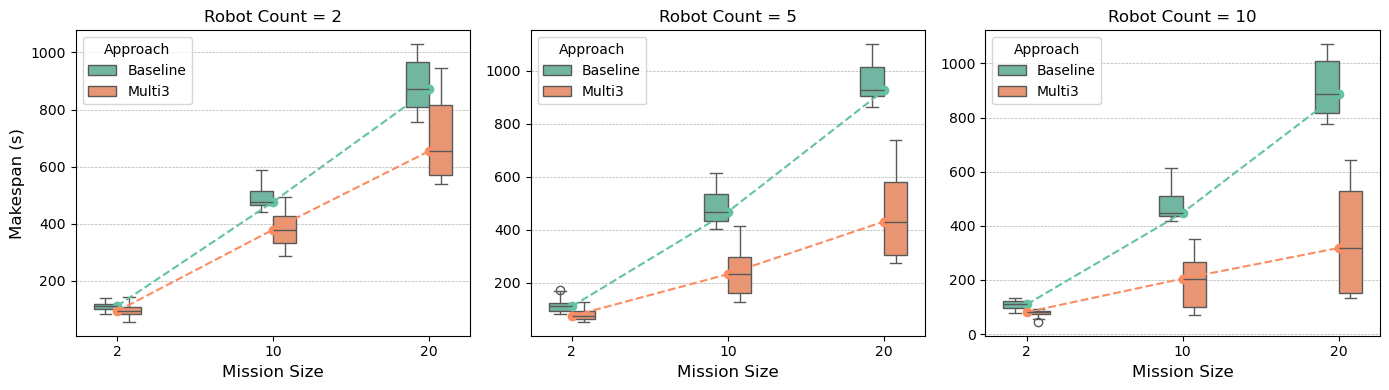

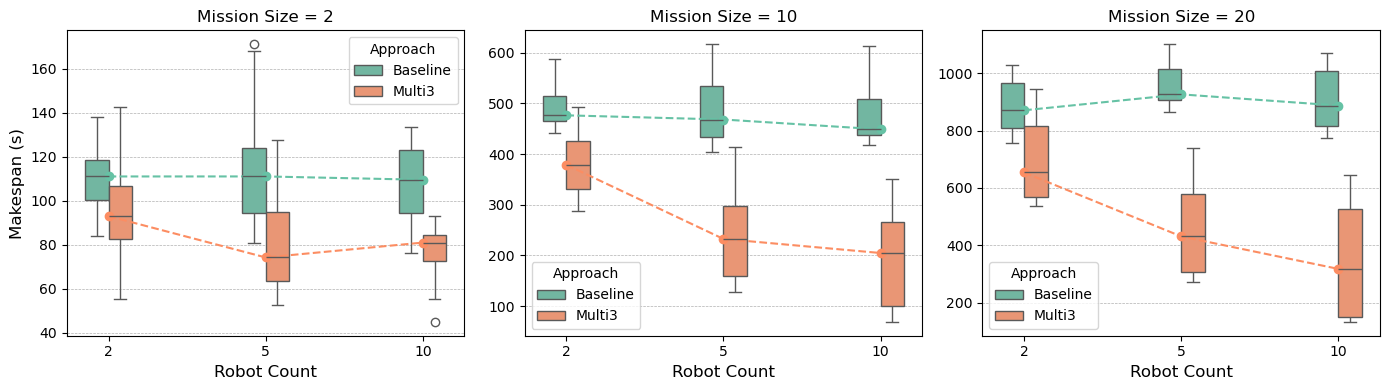

In [10]:
palette = sns.color_palette("Set2")
approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

def multi_box_plot(df,output_file_name, external_variable, var_x, var_y, external_variable_label, x_label, y_label):
    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(14, 4))

    for i, external_variable_value in enumerate(external_variable_values):
        ax = axes[i]
        xx_df = df[df[external_variable] == external_variable_value][[var_x, var_y, "mode"]].copy()
        xx_df["Approach"] = xx_df["mode"].apply(lambda x: "Baseline" if x in {"bl0", "bl1", "bl2"} else "Multi3")

        sns.boxplot(data=xx_df, x=var_x, y=var_y, hue="Approach", palette=approach_colors, width=0.3, ax=ax)

        mission_sizes = sorted(xx_df[var_x].unique())
        x_ticks = range(len(mission_sizes))

        for approach, color in approach_colors.items():
            medians = []
            for size in mission_sizes:
                values = xx_df[(xx_df[var_x] == size) & (xx_df["Approach"] == approach)][var_y]
                if not values.empty:
                    medians.append(np.median(values))
                else:
                    medians.append(np.nan)

            ax.plot(x_ticks, medians, marker="o", linestyle="--", color=color)

        ax.set_title(f"{external_variable_label} = {external_variable_value}")
        ax.set_xlabel(x_label, fontsize=12)
        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")
        ax.yaxis.grid(True, linestyle="--", linewidth=0.5)

    plt.tight_layout()
    plt.savefig(output_file_name, format="pdf")
    plt.show()

multi_box_plot(df_mission, "../output/images/ms_by_mission_size_box.pdf", "robot_count", "mission_size", "makespan", "Robot Count", "Mission Size", "Makespan (s)")
multi_box_plot(df_mission, "../output/images/ms_by_robot_count_box.pdf", "mission_size", "robot_count", "makespan", "Mission Size", "Robot Count", "Makespan (s)")

#### Data analysis

Grouping baseline execution and compute average

In [11]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_baseline = df_mission[df_mission["mode"].isin(["bl0", "bl1", "bl2"])]

df_baseline_avg = (
    df_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "makespan": "mean",
        "average_robot_idle_time": "mean"
    })
)

df_baseline_avg["mode"] = "baseline"

df_multi3 = df_mission[df_mission["mode"] == "multi3"].copy()

df_grouped = pd.concat([df_baseline_avg, df_multi3], ignore_index=True)

df_grouped = df_grouped[group_cols + ["mode", "makespan", "average_robot_idle_time"]]
df_grouped

,scenario,robot_count,mission_size,inventory_id,mode,makespan,average_robot_idle_time
0,agriculture,2,2,0,baseline,111.004905,55.488218
1,agriculture,2,2,1,baseline,121.005003,59.730020
2,agriculture,2,2,2,baseline,102.004999,49.236472
3,agriculture,2,10,0,baseline,470.502052,223.899997
4,agriculture,2,10,1,baseline,453.005083,222.151622
...,...,...,...,...,...,...,...
211,logistics,5,2,1,multi3,124.501863,90.590570
212,logistics,5,2,2,multi3,114.022306,84.606794
213,surveillance,5,2,0,multi3,52.502000,33.582619
214,surveillance,5,2,1,multi3,88.501911,63.294573


Linearizing experiment modes (baseline vs multi3)

In [12]:
pivot_df = df_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["makespan", "average_robot_idle_time"]
)

pivot_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_df.columns]

pivot_df = pivot_df.reset_index()

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "makespan_baseline",
    "makespan_multi3",
    "average_robot_idle_time_baseline",
    "average_robot_idle_time_multi3",
]
pivot_df = pivot_df[ordered_cols]

pivot_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,average_robot_idle_time_baseline,average_robot_idle_time_multi3
0,agriculture,2,2,0,111.004905,82.502096,55.488218,15.759203
1,agriculture,2,2,1,121.005003,94.502047,59.730020,25.494551
2,agriculture,2,2,2,102.004999,96.010862,49.236472,32.253570
3,agriculture,2,10,0,470.502052,433.501345,223.899997,155.999570
4,agriculture,2,10,1,453.005083,334.502045,222.151622,63.748934
...,...,...,...,...,...,...,...,...
103,surveillance,10,10,1,440.014661,241.502167,393.997338,189.841525
104,surveillance,10,10,2,437.502151,223.502141,391.625508,171.537432
105,surveillance,10,20,0,777.502203,433.502152,697.726706,335.027030
106,surveillance,10,20,1,879.040479,495.040131,784.700253,396.106634


#### Computing differences per experiment configuration

In [13]:
makespans_df = pivot_df[["scenario", "robot_count", "mission_size", "inventory_id", "makespan_baseline", "makespan_multi3"]].copy()

makespans_df["makespan_diff"] = makespans_df["makespan_multi3"] - makespans_df["makespan_baseline"]
makespans_df["makespan_diff_percentage"] = (makespans_df["makespan_diff"] / makespans_df["makespan_baseline"]) * 100

makespans_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,makespan_diff,makespan_diff_percentage
0,agriculture,2,2,0,111.004905,82.502096,-28.502809,-25.677071
1,agriculture,2,2,1,121.005003,94.502047,-26.502956,-21.902364
2,agriculture,2,2,2,102.004999,96.010862,-5.994138,-5.876317
3,agriculture,2,10,0,470.502052,433.501345,-37.000707,-7.864090
4,agriculture,2,10,1,453.005083,334.502045,-118.503037,-26.159317
...,...,...,...,...,...,...,...,...
103,surveillance,10,10,1,440.014661,241.502167,-198.512494,-45.114973
104,surveillance,10,10,2,437.502151,223.502141,-214.000010,-48.914047
105,surveillance,10,20,0,777.502203,433.502152,-344.000051,-44.244254
106,surveillance,10,20,1,879.040479,495.040131,-384.000348,-43.684035


In [14]:
makespans_stats = (
    makespans_df.groupby(["mission_size", "robot_count"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["mission_size", "robot_count", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,mission_size,robot_count,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,2,-35.091101,7.139774,-14.547494,-12.241532
1,2,5,-42.630548,-14.600095,-29.807361,-29.834268
2,2,10,-43.710569,-16.676859,-29.662533,-28.984091
3,10,2,-37.920352,-7.864090,-22.489850,-19.924900
4,10,5,-71.875077,-29.628737,-50.346943,-50.284636
5,10,10,-84.743049,-39.361790,-59.927802,-54.301803
6,20,2,-40.155998,-2.441722,-20.474173,-19.851284
7,20,5,-70.737819,-29.672725,-51.995902,-52.157433
8,20,10,-86.515127,-39.860441,-62.085182,-62.110054


In [15]:
makespans_stats = (
    makespans_df.groupby(["mission_size"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["mission_size", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,mission_size,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,-43.710569,7.139774,-24.672463,-25.680023
1,10,-84.743049,-7.864090,-44.254865,-40.933847
2,20,-86.515127,-2.441722,-44.851752,-40.027800


In [16]:
makespans_stats = (
    makespans_df.groupby(["robot_count"])
    .agg({
        "makespan_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

makespans_stats.columns = ["robot_count", "min_makespan_diff_percentage", "max_makespan_diff_percentage", "mean_makespan_diff_percentage", "median_makespan_diff_percentage"]

makespans_stats

,robot_count,min_makespan_diff_percentage,max_makespan_diff_percentage,mean_makespan_diff_percentage,median_makespan_diff_percentage
0,2,-40.155998,7.139774,-19.170506,-17.394521
1,5,-71.875077,-14.600095,-44.050069,-38.647709
2,10,-86.515127,-16.676859,-50.558506,-43.697302


#### Computing average values per scenario

In [17]:
df_completion_average = (
    makespans_df.groupby("scenario")
      .agg({
          "makespan_baseline": "mean",
          "makespan_multi3": "mean",
          "makespan_diff": "mean",
          "makespan_diff_percentage": "mean"
      })
      .reset_index()
)

df_completion_average.rename(columns={"makespan_diff_percentage": "average_of_makespan_diff_percentage"}, inplace=True)

df_completion_average["diff_percentage_on_average_times"] = (df_completion_average["makespan_multi3"] - df_completion_average["makespan_baseline"]) / df_completion_average["makespan_baseline"] * 100

df_completion_average

,scenario,makespan_baseline,makespan_multi3,makespan_diff,average_of_makespan_diff_percentage,diff_percentage_on_average_times
0,agriculture,478.625116,225.787798,-252.837319,-45.414503,-52.825752
1,cleaning,499.901373,193.013468,-306.887906,-53.546305,-61.389690
2,logistics,583.124137,420.622763,-162.501374,-24.233532,-27.867372
3,surveillance,463.438402,318.512838,-144.925563,-28.511101,-31.271807


#### Plotting average completion times per scenario

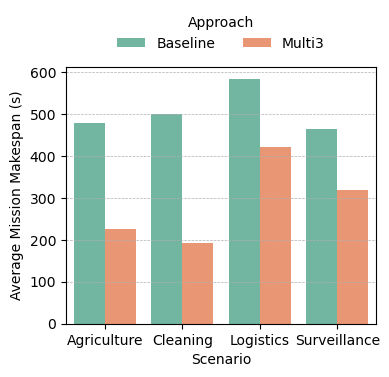

In [18]:
melted = df_completion_average.melt(id_vars='scenario', value_vars=['makespan_baseline', 'makespan_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'makespan_baseline': 'Baseline', 'makespan_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Average Mission Makespan (s)')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/images/ms_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

## EQ3: Analyzing improvements in idle times

#### Computing idle time ratios per experiment configuration

Metric:

$IdleRatio = \frac{\sum_{r} IdleTime_{r}}{|R| \times CompletionTime}$

where $R$ is the set of robots involved in the mission

In [19]:
idle_times_df = pivot_df[["scenario", "robot_count", "mission_size", "inventory_id", "makespan_baseline", "makespan_multi3", "average_robot_idle_time_baseline", "average_robot_idle_time_multi3"]].copy()

idle_times_df["average_robot_idle_time_diff_percentage"] = (idle_times_df["average_robot_idle_time_multi3"] - idle_times_df["average_robot_idle_time_baseline"]) / idle_times_df["average_robot_idle_time_baseline"] * 100

idle_times_df["idle_ratio_baseline"] = idle_times_df["average_robot_idle_time_baseline"] / idle_times_df["makespan_baseline"]
idle_times_df["idle_ratio_multi3"] = idle_times_df["average_robot_idle_time_multi3"] / idle_times_df["makespan_multi3"]

idle_times_df["idle_ratio_diff_percentage"] = (idle_times_df["idle_ratio_multi3"] - idle_times_df["idle_ratio_baseline"]) / idle_times_df["idle_ratio_baseline"] * 100

idle_times_df

,scenario,robot_count,mission_size,inventory_id,makespan_baseline,makespan_multi3,average_robot_idle_time_baseline,average_robot_idle_time_multi3,average_robot_idle_time_diff_percentage,idle_ratio_baseline,idle_ratio_multi3,idle_ratio_diff_percentage
0,agriculture,2,2,0,111.004905,82.502096,55.488218,15.759203,-71.599010,0.499872,0.191016,-61.787042
1,agriculture,2,2,1,121.005003,94.502047,59.730020,25.494551,-57.317022,0.493616,0.269778,-45.346645
2,agriculture,2,2,2,102.004999,96.010862,49.236472,32.253570,-34.492524,0.482687,0.335937,-30.402770
3,agriculture,2,10,0,470.502052,433.501345,223.899997,155.999570,-30.326229,0.475875,0.359859,-24.379353
4,agriculture,2,10,1,453.005083,334.502045,222.151622,63.748934,-71.303863,0.490395,0.190579,-61.137768
...,...,...,...,...,...,...,...,...,...,...,...,...
103,surveillance,10,10,1,440.014661,241.502167,393.997338,189.841525,-51.816546,0.895419,0.786086,-12.210203
104,surveillance,10,10,2,437.502151,223.502141,391.625508,171.537432,-56.198606,0.895140,0.767498,-14.259416
105,surveillance,10,20,0,777.502203,433.502152,697.726706,335.027030,-51.983058,0.897395,0.772838,-13.879831
106,surveillance,10,20,1,879.040479,495.040131,784.700253,396.106634,-49.521281,0.892678,0.800151,-10.365172


#### Plotting idle ratios for each experimental run

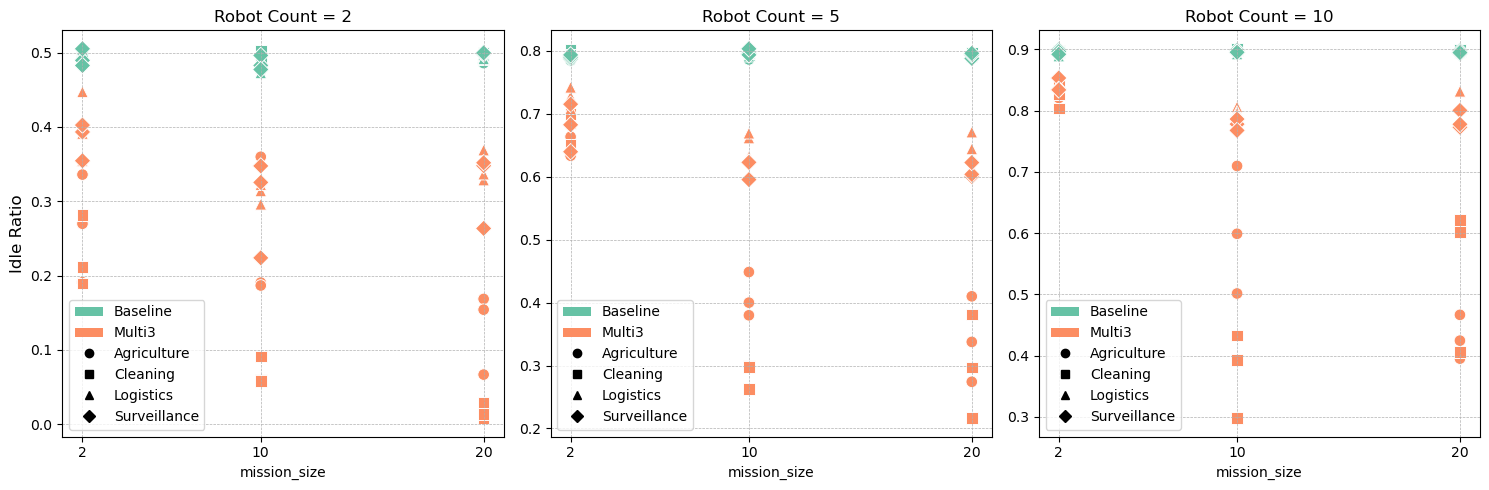

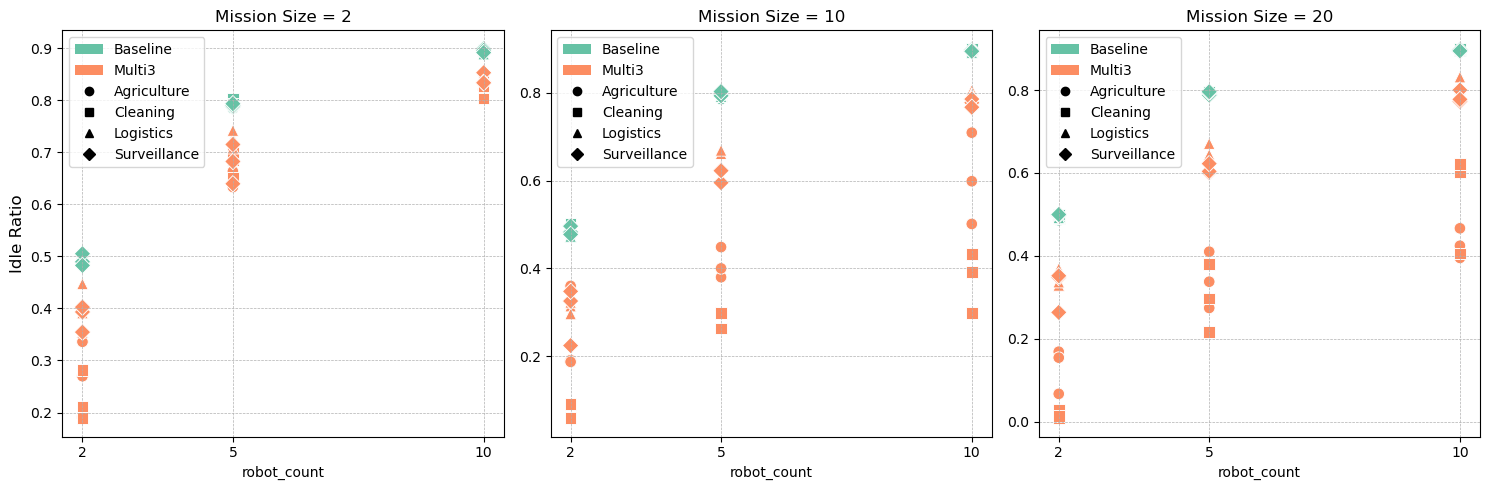

In [20]:
def multiplot_columns(df, fname, external_variable, var_x, baseline_col, multi3_col, title, x_label, y_label):
    marker_dict = {
        "agriculture": "o",
        "cleaning": "s",
        "logistics": "^",
        "surveillance": "D",
        "other": "v"
    }

    palette = sns.color_palette("Set2")
    approach_colors = {"Baseline": palette[0], "Multi3": palette[1]}

    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(5 * len(external_variable_values), 5), squeeze=False)
    axes = axes[0]

    for i, v in enumerate(external_variable_values):
        ax = axes[i]

        x_df = df[df[external_variable] == v].copy()

        x_df = x_df.melt(id_vars=[var_x, "scenario", "inventory_id"], value_vars=[baseline_col, multi3_col], var_name="Approach", value_name="metric_value")

        x_df["Approach"] = x_df["Approach"].replace({baseline_col: "Baseline", multi3_col: "Multi3" })

        for approach in ["Baseline", "Multi3"]:
            approach_df = x_df[x_df["Approach"] == approach]

            sns.scatterplot(
                data=approach_df,
                x=var_x,
                y="metric_value",
                style="scenario",
                color=approach_colors[approach],
                ax=ax,
                markers=marker_dict,
                s=70
            )

        ax.set_title(title.replace("$field$", str(v)))
        ax.set_ylabel(y_label, fontsize=12)
        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")
        ax.set_xticks(sorted(x_df[var_x].unique()))
        ax.grid(True, linestyle="--", linewidth=0.5)

        color_handles = [
            Patch(facecolor=approach_colors["Baseline"], label="Baseline"),
            Patch(facecolor=approach_colors["Multi3"], label="Multi3")
        ]

        scenario_values = sorted(df["scenario"].unique())
        marker_handles = [
            Line2D(
                [0], [0],
                marker=marker_dict.get(s, marker_dict["other"]),
                color="black",
                linestyle="None",
                label=s.capitalize()
            )
            for s in scenario_values
        ]

        ax.legend(handles=color_handles + marker_handles, frameon=True)

    plt.tight_layout()
    plt.savefig(fname, format="pdf", bbox_inches="tight")
    plt.show()

multiplot_columns(idle_times_df, "../output/images/ir_by_mission_size_scatter.pdf", "robot_count", "mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "Robot Count = $field$","Mission Size", "Idle Ratio")
multiplot_columns(idle_times_df, "../output/images/ir_by_robot_count_scatter.pdf", "mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "Mission Size = $field$","Robot Count", "Idle Ratio")

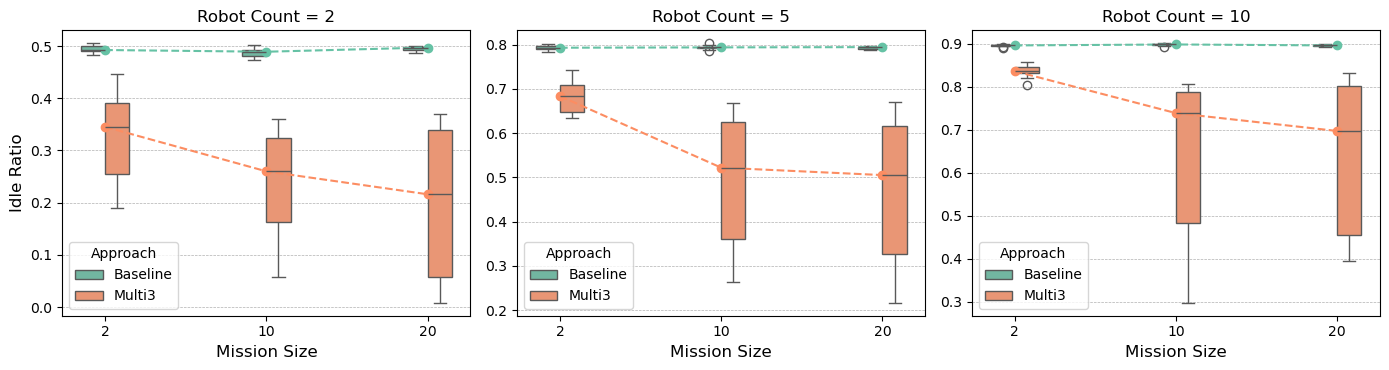

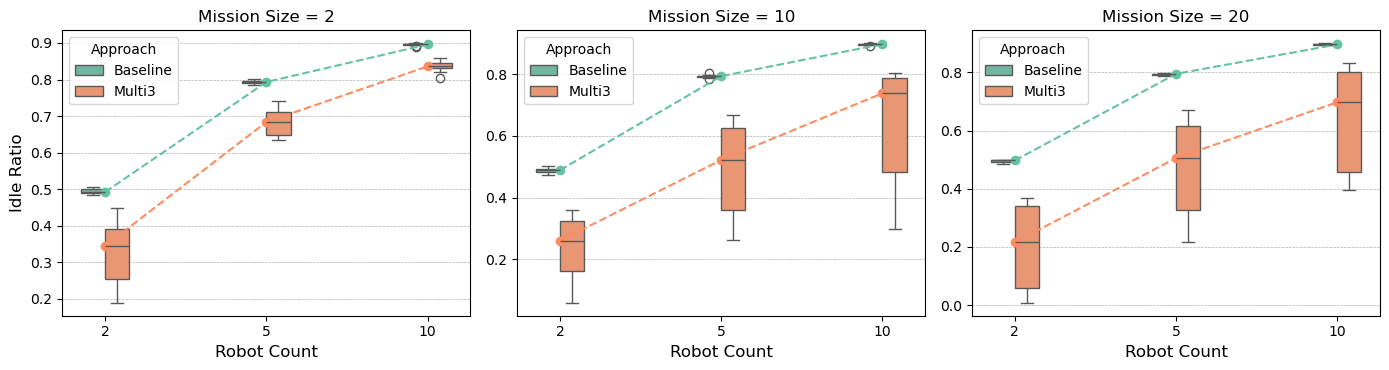

In [21]:
def multi_box_plot_columns(df, output_file_name, external_variable, var_x, baseline_col, multi3_col, external_variable_label, x_label, y_label):
    external_variable_values = sorted(df[external_variable].unique())

    fig, axes = plt.subplots(1, len(external_variable_values), figsize=(14, 4), squeeze=False)
    axes = axes[0]

    for i, external_variable_value in enumerate(external_variable_values):
        ax = axes[i]

        xx_df = df[df[external_variable] == external_variable_value].copy()
        xx_df = xx_df.melt( id_vars=[var_x], value_vars=[baseline_col, multi3_col], var_name="Approach", value_name="metric_value")
        xx_df["Approach"] = xx_df["Approach"].replace({baseline_col: "Baseline", multi3_col: "Multi3"})

        sns.boxplot(data=xx_df, x=var_x, y="metric_value", hue="Approach", palette=approach_colors, width=0.3, ax=ax)

        var_x_values = sorted(xx_df[var_x].unique())
        x_ticks = range(len(var_x_values))

        for approach, color in approach_colors.items():
            medians = []
            for x_val in var_x_values:
                values = xx_df[
                    (xx_df[var_x] == x_val) &
                    (xx_df["Approach"] == approach)
                ]["metric_value"]

                medians.append(np.median(values) if not values.empty else np.nan)

            ax.plot(x_ticks, medians, marker="o", linestyle="--", color=color)

        ax.set_title(f"{external_variable_label} = {external_variable_value}")
        ax.set_xlabel(x_label, fontsize=12)

        if i == 0:
            ax.set_ylabel(y_label, fontsize=12)
        else:
            ax.set_ylabel("")

        ax.yaxis.grid(True, linestyle="--", linewidth=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_file_name, format="pdf", bbox_inches="tight")
    plt.show()

multi_box_plot_columns(idle_times_df, "../output/images/ir_by_mission_size_box.pdf", "robot_count", "mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "Robot Count", "Mission Size", "Idle Ratio")
multi_box_plot_columns(idle_times_df, "../output/images/ir_by_robot_count_box.pdf", "mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "Mission Size", "Robot Count", "Idle Ratio")

#### Computing idle time ratio difference percentages per configuration

In [22]:
idle_ratio_stats = (
    idle_times_df.groupby(["mission_size", "robot_count"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["mission_size", "robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,mission_size,robot_count,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,2,0.494121,0.318552,-61.922959,-8.809455,-35.421467,-30.112359
1,2,5,0.793403,0.682264,-20.008864,-6.442204,-14.018190,-14.123857
2,2,10,0.895327,0.836216,-10.309739,-4.262101,-6.601714,-6.522216
3,10,2,0.487424,0.231319,-88.116622,-24.379353,-52.245668,-47.335225
4,10,5,0.794007,0.490941,-67.003922,-15.465978,-38.204903,-34.125444
5,10,10,0.897471,0.638642,-66.844340,-10.284227,-28.812022,-17.590228
6,20,2,0.495440,0.203107,-98.335417,-24.974878,-59.007409,-56.654732
7,20,5,0.793497,0.472674,-72.792549,-15.206568,-40.422183,-36.252750
8,20,10,0.896218,0.642034,-55.840187,-7.172196,-28.343715,-22.358673


In [23]:
idle_ratio_stats = (
    idle_times_df.groupby(["mission_size"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["mission_size", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,mission_size,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,0.727617,0.612344,-61.922959,-4.262101,-18.680457,-13.361342
1,10,0.726300,0.453634,-88.116622,-10.284227,-39.754198,-33.609814
2,20,0.728385,0.439272,-98.335417,-7.172196,-42.591102,-33.465934


In [24]:
idle_ratio_stats = (
    idle_times_df.groupby(["robot_count"])
    .agg({
        "idle_ratio_baseline": ["mean"],
        "idle_ratio_multi3": ["mean"],
        "idle_ratio_diff_percentage": ["min", "max", "mean", "median"]
    })
    .reset_index()
)

idle_ratio_stats.columns = ["robot_count", "idle_ratio_baseline", "idle_ratio_multi3", "min_idle_ratio_diff_percentage", "max_idle_ratio_diff_percentage", "mean_idle_ratio_diff_percentage", "median_idle_ratio_diff_percentage"]

idle_ratio_stats

,robot_count,idle_ratio_baseline,idle_ratio_multi3,min_idle_ratio_diff_percentage,max_idle_ratio_diff_percentage,mean_idle_ratio_diff_percentage,median_idle_ratio_diff_percentage
0,2,0.492328,0.250992,-98.335417,-8.809455,-48.891514,-41.197558
1,5,0.793635,0.548627,-72.792549,-6.442204,-30.881759,-21.644269
2,10,0.896338,0.705631,-66.844340,-4.262101,-21.252484,-10.921954


#### Computing idle time ratio averages per scenario

In [25]:
idle_times_average_df = (
    idle_times_df.groupby("scenario")
      .agg({
          "average_robot_idle_time_baseline": "mean",
          "average_robot_idle_time_multi3": "mean",
          "average_robot_idle_time_diff_percentage": "mean",
          "idle_ratio_baseline": "mean",
          "idle_ratio_multi3": "mean",
          "idle_ratio_diff_percentage": "mean"
      })
      .reset_index()
)

idle_times_average_df.rename(columns={"average_robot_idle_time_diff_percentage": "average_of_average_robot_idle_time_diff_percentage", "idle_ratio_diff_percentage": "average_of_idle_ratio_diff_percentage"}, inplace=True)

idle_times_average_df["diff_percentage_on_average_robot_idle_time"] = (idle_times_average_df["average_robot_idle_time_multi3"] - idle_times_average_df["average_robot_idle_time_baseline"]) / idle_times_average_df["average_robot_idle_time_baseline"] * 100

idle_times_average_df["diff_percentage_on_average_ratios"] = (idle_times_average_df["idle_ratio_multi3"] - idle_times_average_df["idle_ratio_baseline"]) / idle_times_average_df["idle_ratio_baseline"] * 100

idle_times_average_df

,scenario,average_robot_idle_time_baseline,average_robot_idle_time_multi3,average_of_average_robot_idle_time_diff_percentage,idle_ratio_baseline,idle_ratio_multi3,average_of_idle_ratio_diff_percentage,diff_percentage_on_average_robot_idle_time,diff_percentage_on_average_ratios
0,agriculture,347.006624,73.567213,-67.839689,0.725928,0.433213,-42.714701,-78.799479,-40.322887
1,cleaning,365.270924,42.916769,-78.203926,0.729850,0.368882,-53.764716,-88.250702,-49.457859
2,logistics,425.707010,240.690738,-37.852697,0.726789,0.615316,-17.316574,-43.460941,-15.337730
3,surveillance,338.581053,171.289706,-44.169784,0.727169,0.589589,-20.905018,-49.409542,-18.919947


#### Plotting average idle times per scenario

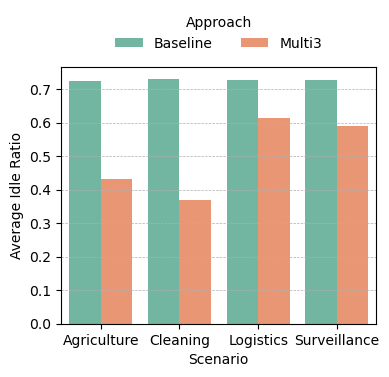

In [26]:
melted = idle_times_average_df.melt(id_vars='scenario', value_vars=['idle_ratio_baseline', 'idle_ratio_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'idle_ratio_baseline': 'Baseline', 'idle_ratio_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Average Idle Ratio')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/images/ir_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

## EQ4 (first part): Analyzing workload variance

Metric:

$WorkloadVariance = \frac{1}{|R|} \sum_{r \in R}​(W_r ​ − \overline{W})^2$

where: $\overline{W} = \frac{1}{|R|} \sum_{r \in R}​W_r$, and $W_r$ is the active time of robot $r \in R$

$CV = \frac{\sqrt{WorkloadVariance}}{\overline{W}}$

In [27]:
workload_df = mission_data_df.copy()

workload_df["workload"] = workload_df["makespan"] - workload_df["robot_idle_time"]

workload_df

,test_id,robot_count,mission_size,inventory_id,scenario,mode,makespan,robot_id,robot_idle_time,workload
0,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_1,68.891119,25.610923
1,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_2,73.427535,21.074506
2,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_3,77.964169,16.537873
3,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_4,83.964793,10.537248
4,test_10_2_t_logistics_i1_bl1,10,2,1,logistics,bl1,94.502042,robot_5,94.502042,0.000000
...,...,...,...,...,...,...,...,...,...,...
2443,test_5_10_t_agriculture_i2_bl2,5,10,2,agriculture,bl2,435.021733,robot_1,158.905609,276.116124
2444,test_5_10_t_agriculture_i2_bl2,5,10,2,agriculture,bl2,435.021733,robot_2,386.944697,48.077036
2445,test_5_10_t_agriculture_i2_bl2,5,10,2,agriculture,bl2,435.021733,robot_3,422.982018,12.039715
2446,test_5_10_t_agriculture_i2_bl2,5,10,2,agriculture,bl2,435.021733,robot_4,421.501656,13.520078


In [28]:
group_cols = ["robot_count", "mission_size", "inventory_id", "scenario", "mode"]
workload_variance_df = (
    workload_df
    .groupby(group_cols)
    .agg(
        workload_mean=("workload", "mean"),
        workload_var=("workload", lambda x: x.var(ddof=0)),
        workload_std=("workload", lambda x: x.std(ddof=0))
    )
    .reset_index()
)

workload_variance_df["workload_cv"] = workload_variance_df["workload_std"] / workload_variance_df["workload_mean"]

workload_variance_df

,robot_count,mission_size,inventory_id,scenario,mode,workload_mean,workload_var,workload_std,workload_cv
0,2,2,0,agriculture,bl0,55.514727,506.096208,22.496582,0.405236
1,2,2,0,agriculture,bl1,56.267393,5.076761,2.253167,0.040044
2,2,2,0,agriculture,bl2,54.767940,409.739948,20.242034,0.369596
3,2,2,0,agriculture,multi3,66.742893,68.181925,8.257235,0.123717
4,2,2,0,cleaning,bl0,57.761864,94.954898,9.744480,0.168701
...,...,...,...,...,...,...,...,...,...
427,10,20,2,logistics,multi3,107.982741,13947.783713,118.100735,1.093700
428,10,20,2,surveillance,bl0,89.372885,18514.378489,136.067551,1.522470
429,10,20,2,surveillance,bl1,89.382009,18429.821318,135.756478,1.518834
430,10,20,2,surveillance,bl2,89.679989,19343.662948,139.081498,1.550864


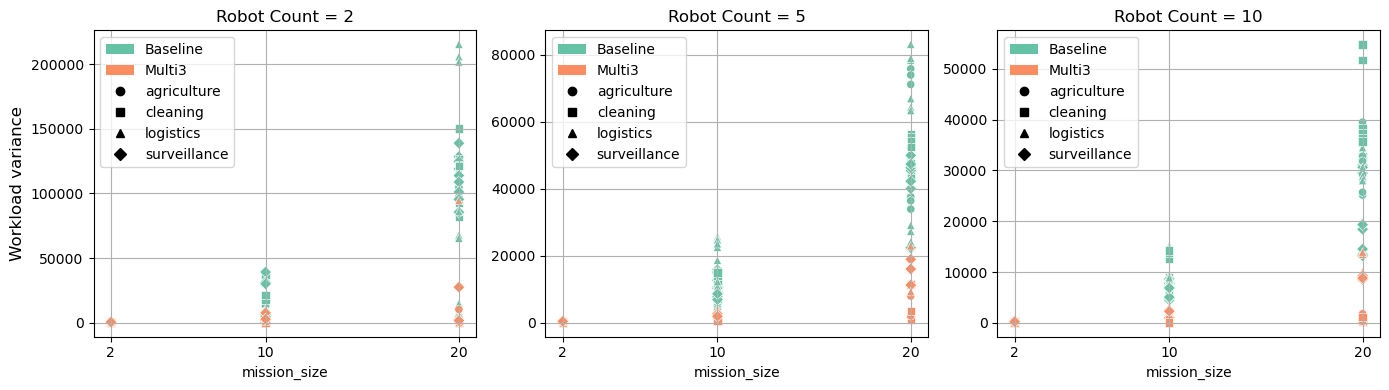

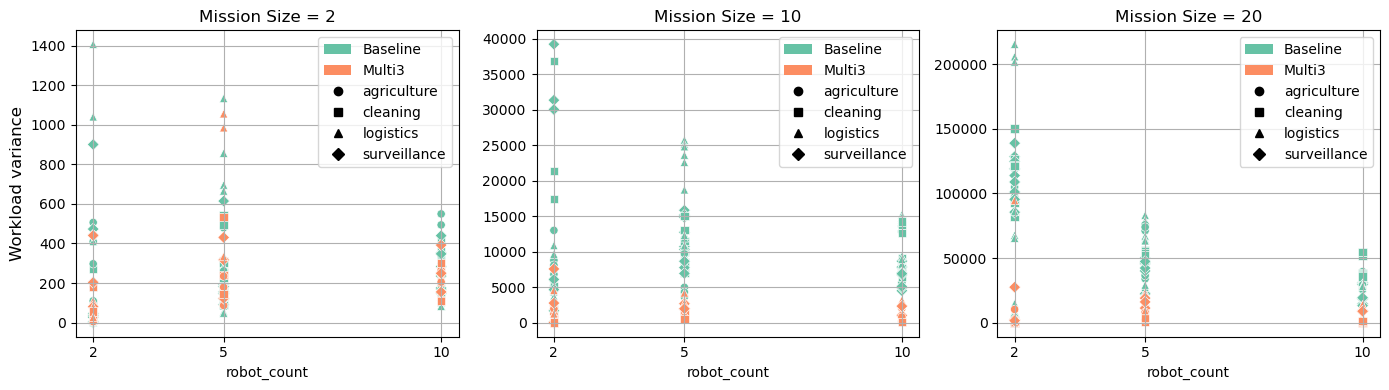

In [29]:
multiplot(workload_variance_df, "../output/images/wv_by_mission_size_scatter.pdf", "robot_count", "mission_size","workload_var","Robot Count = $field$", "Mission Size", "Workload variance")
multiplot(workload_variance_df, "../output/images/wv_by_robot_count_scatter.pdf", "mission_size", "robot_count","workload_var","Mission Size = $field$", "Robot Count", "Workload variance")

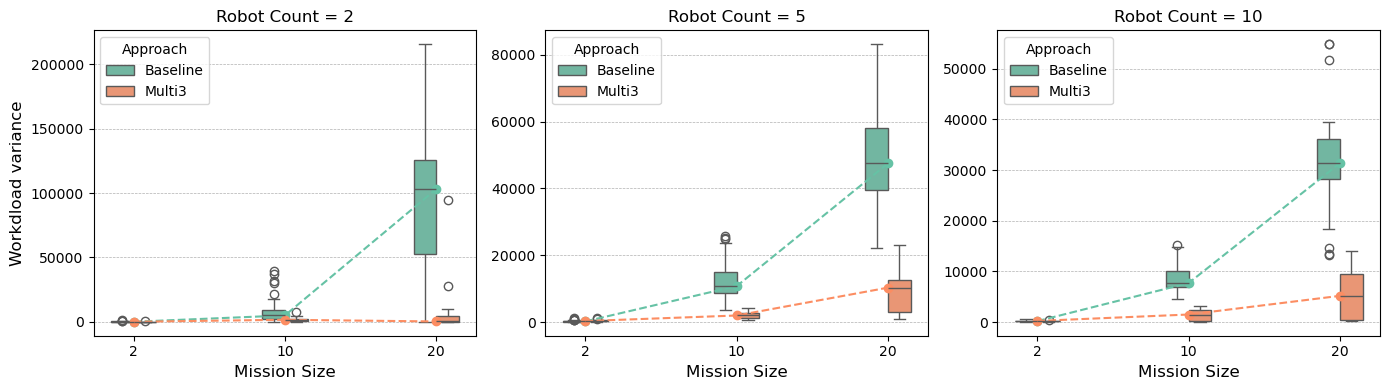

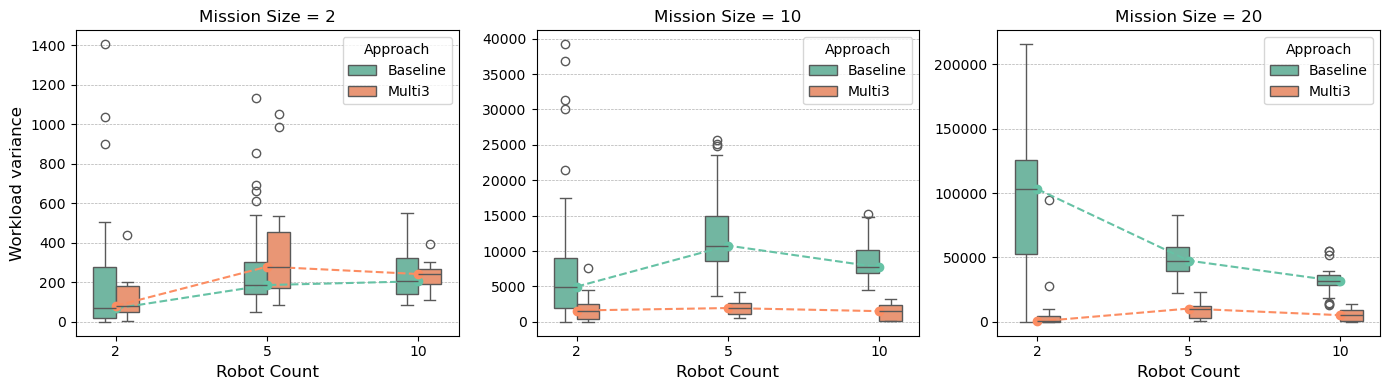

In [30]:
multi_box_plot(workload_variance_df, "../output/images/wv_by_mission_size_box.pdf", "robot_count", "mission_size", "workload_var", "Robot Count", "Mission Size", "Workdload variance")
multi_box_plot(workload_variance_df, "../output/images/wv_by_robot_count_box.pdf", "mission_size", "robot_count", "workload_var", "Mission Size", "Robot Count", "Workload variance")

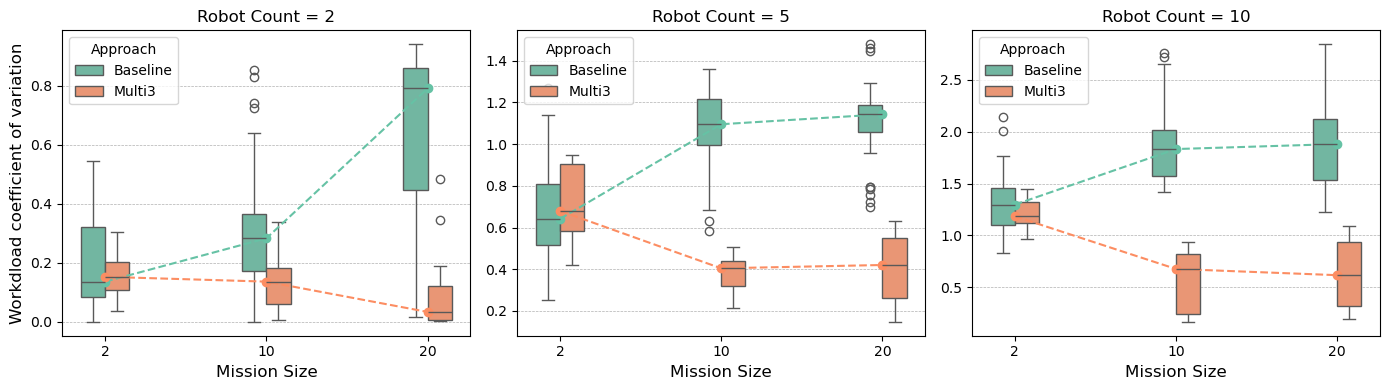

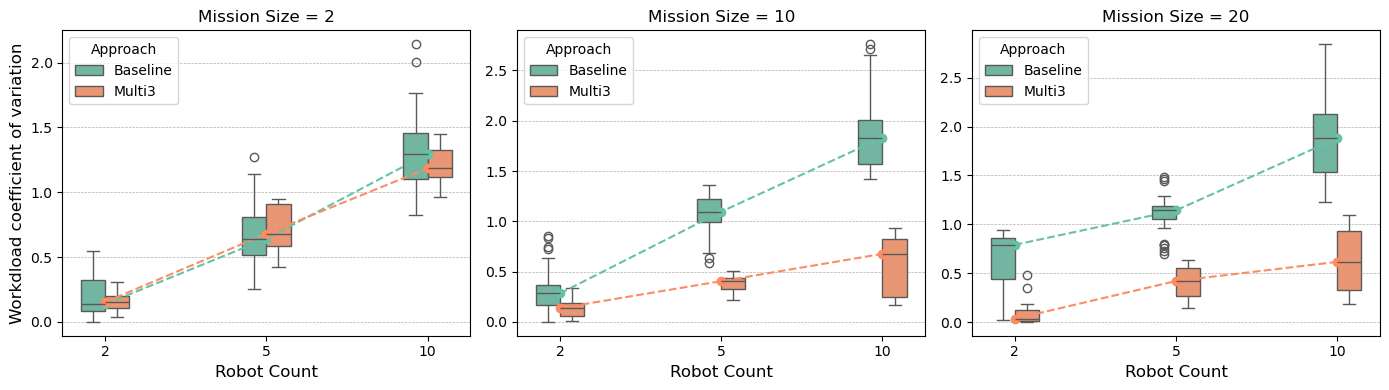

In [31]:
multi_box_plot(workload_variance_df, "../output/images/cv_by_mission_size_box.pdf", "robot_count", "mission_size", "workload_cv", "Robot Count", "Mission Size", "Workdload coefficient of variation")
multi_box_plot(workload_variance_df, "../output/images/cv_by_robot_count_box.pdf", "mission_size", "robot_count", "workload_cv", "Mission Size", "Robot Count", "Workdload coefficient of variation")

In [32]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_workload_baseline = workload_variance_df[workload_variance_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_workload_baseline_avg = (
    df_workload_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "workload_var": "mean",
        "workload_std": "mean",
        "workload_cv": "mean"
    })
)

df_workload_baseline_avg["mode"] = "baseline"

df_workload_multi3 = workload_variance_df[workload_variance_df["mode"] == "multi3"].copy()

df_workload_grouped = pd.concat([df_workload_baseline_avg, df_workload_multi3], ignore_index=True)

df_workload_grouped = df_workload_grouped[group_cols + ["mode", "workload_var", "workload_std", "workload_cv"]]
df_workload_grouped

,scenario,robot_count,mission_size,inventory_id,mode,workload_var,workload_std,workload_cv
0,agriculture,2,2,0,baseline,306.970973,14.997261,0.271626
1,agriculture,2,2,1,baseline,68.494071,7.752657,0.126990
2,agriculture,2,2,2,baseline,105.479827,7.745828,0.148826
3,agriculture,2,10,0,baseline,7861.418267,84.999921,0.347245
4,agriculture,2,10,1,baseline,6607.644418,80.745456,0.349883
...,...,...,...,...,...,...,...,...
211,surveillance,10,20,1,multi3,8570.312782,92.575984,0.935740
212,agriculture,10,20,2,multi3,300.733694,17.341675,0.189168
213,cleaning,10,20,2,multi3,1222.904742,34.970055,0.353537
214,logistics,10,20,2,multi3,13947.783713,118.100735,1.093700


In [33]:
pivot_workload_df = df_workload_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["workload_var", "workload_std", "workload_cv"]
)

pivot_workload_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_workload_df.columns]

pivot_workload_df = pivot_workload_df.reset_index()

pivot_workload_df["workload_var_diff_percentage"] = (
    (pivot_workload_df["workload_var_multi3"] - pivot_workload_df["workload_var_baseline"])
    / pivot_workload_df["workload_var_baseline"]
) * 100

pivot_workload_df["workload_cv_diff_percentage"] = (
    (pivot_workload_df["workload_cv_multi3"] - pivot_workload_df["workload_cv_baseline"])
    / pivot_workload_df["workload_cv_baseline"]
) * 100

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "workload_var_baseline",
    "workload_var_multi3",
    "workload_var_diff_percentage",
    "workload_std_baseline",
    "workload_std_multi3",
    "workload_cv_baseline",
    "workload_cv_multi3",
    "workload_cv_diff_percentage",
]

pivot_workload_df = pivot_workload_df[ordered_cols]

pivot_workload_df

,scenario,robot_count,mission_size,inventory_id,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,agriculture,2,2,0,306.970973,68.181925,-77.788804,14.997261,8.257235,0.271626,0.123717,-54.453082
1,agriculture,2,2,1,68.494071,182.269483,166.109870,7.752657,13.500722,0.126990,0.195641,54.061062
2,agriculture,2,2,2,105.479827,5.065308,-95.197842,7.745828,2.250624,0.148826,0.035300,-76.281131
3,agriculture,2,10,0,7861.418267,1189.922107,-84.863773,84.999921,34.495248,0.347245,0.124306,-64.202082
4,agriculture,2,10,1,6607.644418,2377.076051,-64.025364,80.745456,48.755267,0.349883,0.180073,-48.533404
...,...,...,...,...,...,...,...,...,...,...,...,...
103,surveillance,10,10,1,4839.906761,2334.629309,-51.762928,69.546840,48.318002,1.511192,0.935296,-38.108721
104,surveillance,10,10,2,6883.164016,2320.747969,-66.283704,82.962567,48.174142,1.808646,0.927055,-48.743143
105,surveillance,10,20,0,30382.049840,9276.450352,-69.467332,174.294176,96.314331,2.184811,0.978057,-55.233774
106,surveillance,10,20,1,13756.586496,8570.312782,-37.700295,117.263418,92.575984,1.242921,0.935740,-24.714480


#### Cleaning from outliers

In [34]:
numeric_cols = pivot_workload_df.select_dtypes(include=np.number).columns
negative_rows = pivot_workload_df[(pivot_workload_df[numeric_cols] > 0).any(axis=1)]
negative_rows

,scenario,robot_count,mission_size,inventory_id,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,agriculture,2,2,0,306.970973,68.181925,-77.788804,14.997261,8.257235,0.271626,0.123717,-54.453082
1,agriculture,2,2,1,68.494071,182.269483,166.109870,7.752657,13.500722,0.126990,0.195641,54.061062
2,agriculture,2,2,2,105.479827,5.065308,-95.197842,7.745828,2.250624,0.148826,0.035300,-76.281131
3,agriculture,2,10,0,7861.418267,1189.922107,-84.863773,84.999921,34.495248,0.347245,0.124306,-64.202082
4,agriculture,2,10,1,6607.644418,2377.076051,-64.025364,80.745456,48.755267,0.349883,0.180073,-48.533404
...,...,...,...,...,...,...,...,...,...,...,...,...
103,surveillance,10,10,1,4839.906761,2334.629309,-51.762928,69.546840,48.318002,1.511192,0.935296,-38.108721
104,surveillance,10,10,2,6883.164016,2320.747969,-66.283704,82.962567,48.174142,1.808646,0.927055,-48.743143
105,surveillance,10,20,0,30382.049840,9276.450352,-69.467332,174.294176,96.314331,2.184811,0.978057,-55.233774
106,surveillance,10,20,1,13756.586496,8570.312782,-37.700295,117.263418,92.575984,1.242921,0.935740,-24.714480


In [35]:
pivot_workload_df = pivot_workload_df.drop(84)

#### Computing averages per configuration

In [36]:
workload_average_df = (
    pivot_workload_df.groupby(["mission_size", "robot_count"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["mission_size", "robot_count", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,mission_size,robot_count,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,2,211.195058,120.945988,8.495078,0.195435,0.157038,-5.589969
1,2,5,285.627223,388.734631,61.874296,0.678846,0.717692,13.179745
2,2,10,238.170712,229.208046,16.819957,1.323115,1.205746,-4.758676
3,10,2,9408.423520,1543.157778,-67.039126,0.341768,0.111931,-56.160454
4,10,5,12375.448990,1970.346110,-81.837354,1.085735,0.378617,-63.851151
5,10,10,8804.383522,1482.055332,-80.416709,1.891043,0.586199,-66.155287
6,20,2,91839.760939,11414.533416,-91.836695,0.628171,0.107760,-84.131899
7,20,5,49419.424313,9788.936707,-78.177723,1.107444,0.412719,-61.496656
8,20,10,31646.479875,5720.822633,-77.137636,1.879676,0.625174,-62.757243


In [37]:
workload_average_df = (
    pivot_workload_df.groupby(["robot_count"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["robot_count", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,robot_count,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,34517.260877,4440.013954,-49.643708,0.389792,0.125966,-48.412212
1,5,20693.500175,4049.339149,-32.713594,0.957342,0.503009,-37.389354
2,10,13563.011370,2477.362004,-46.911463,1.697945,0.805706,-44.557069


In [38]:
workload_average_df = (
    pivot_workload_df.groupby(["mission_size"])
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.columns = ["mission_size", "workload_var_baseline", "workload_var_multi3", "workload_var_diff_percentage", "workload_cv_baseline", "workload_cv_multi3", "workload_cv_diff_percentage"]

workload_average_df

,mission_size,workload_var_baseline,workload_var_multi3,workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,workload_cv_diff_percentage
0,2,244.997664,246.296222,29.063111,0.732465,0.693492,0.943700
1,10,10218.589968,1668.672939,-76.699404,1.128023,0.365972,-62.224064
2,20,57635.221709,8974.764252,-82.384018,1.205097,0.381884,-69.461933


#### Computing averages per scenario

In [39]:
workload_average_df = (
    pivot_workload_df.groupby("scenario")
      .agg({
          "workload_var_baseline": "mean",
          "workload_var_multi3": "mean",
          "workload_var_diff_percentage": "mean",
          "workload_std_baseline": "mean",
          "workload_std_multi3": "mean",
          "workload_cv_baseline": "mean",
          "workload_cv_multi3": "mean",
          "workload_cv_diff_percentage": "mean"
      })
      .reset_index()
)

workload_average_df.rename(columns={"workload_var_diff_percentage": "average_of_workload_var_diff_percentage", "workload_cv_diff_percentage": "average_of_workload_cv_diff_percentage"}, inplace=True)

workload_average_df["diff_percentage_on_average_workload_var"] = (workload_average_df["workload_var_multi3"] - workload_average_df["workload_var_baseline"]) / workload_average_df["workload_var_baseline"] * 100
workload_average_df["diff_percentage_on_average_workload_cv"] = (workload_average_df["workload_cv_multi3"] - workload_average_df["workload_cv_baseline"]) / workload_average_df["workload_cv_baseline"] * 100

workload_average_df

,scenario,workload_var_baseline,workload_var_multi3,average_of_workload_var_diff_percentage,workload_std_baseline,workload_std_multi3,workload_cv_baseline,workload_cv_multi3,average_of_workload_cv_diff_percentage,diff_percentage_on_average_workload_var,diff_percentage_on_average_workload_cv
0,agriculture,21088.092065,1458.764365,-58.623094,105.861692,30.530924,1.033696,0.375568,-53.424217,-93.082521,-63.667477
1,cleaning,22096.881225,846.651474,-67.359221,108.274067,19.800559,1.097216,0.372464,-58.653265,-96.168457,-66.053740
2,logistics,24700.599763,7637.910530,-20.873206,115.918297,60.979146,0.910371,0.578809,-30.528639,-69.078036,-36.420527
3,surveillance,23401.079766,4688.150690,-24.574337,113.038198,52.801101,1.043015,0.603765,-30.543591,-79.966092,-42.113488


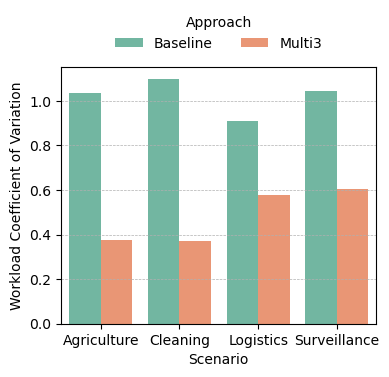

In [40]:
melted = workload_average_df.melt(id_vars='scenario', value_vars=['workload_cv_baseline', 'workload_cv_multi3'], var_name='mode', value_name='coefficient')

melted['mode'] = melted['mode'].replace({'workload_cv_baseline': 'Baseline', 'workload_cv_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='coefficient', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Workload Coefficient of Variation')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/images/cv_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

## EQ4 (second part): Analyzing concurrency ratio

## Metric

$CR = \frac{1}{T} \int_0^T A(t)\, dt$,

where $T$ is the mission completion time, and $A(t) = |\{r \in R | r$ is executing a task at time $t\}|$.

In [41]:
with open("../output/robot_data.json", 'r') as f:
    robot_execution_data = json.load(f)

In [42]:
results = []

for mission_id, mission_data in robot_execution_data.items():
    T = mission_data["mission_duration"]
    robots = mission_data["robots"]

    labels = mission_id.split("_")
    robot_count = int(labels[1])
    mission_size = int(labels[2])
    inv_id = int(labels[5][1])
    scenario = labels[4]
    mode = labels[6]

    total_active_time = 0

    for robot_name, robot_data in robots.items():
        intervals = robot_data["non_idle_intervals"]

        robot_active_time = sum(interval[1] for interval in intervals)
        total_active_time += robot_active_time

    cr = total_active_time / T if T > 0 else 0

    results.append({
        "scenario": scenario,
        "robot_count": robot_count,
        "mission_size": mission_size,
        "inventory_id": inv_id,
        "mode": mode,
        "mission_duration": T,
        "total_active_time": total_active_time,
        "CR": cr
    })

concurrency_ratio_df = pd.DataFrame(results)
concurrency_ratio_df

,scenario,robot_count,mission_size,inventory_id,mode,mission_duration,total_active_time,CR
0,logistics,10,2,1,bl1,94.502042,100.759706,1.066217
1,surveillance,5,20,1,multi3,549.019178,1087.779470,1.981314
2,cleaning,10,20,0,bl2,987.040086,1009.445137,1.022699
3,surveillance,10,20,2,bl0,847.502219,893.728847,1.054545
4,agriculture,2,10,1,bl0,454.502148,465.216632,1.023574
...,...,...,...,...,...,...,...,...
427,logistics,5,20,2,multi3,703.502310,1251.794922,1.779376
428,logistics,2,10,2,bl2,520.502142,525.297694,1.009213
429,cleaning,2,20,0,bl0,955.501359,976.743764,1.022232
430,cleaning,2,2,1,multi3,78.010538,123.002455,1.576742


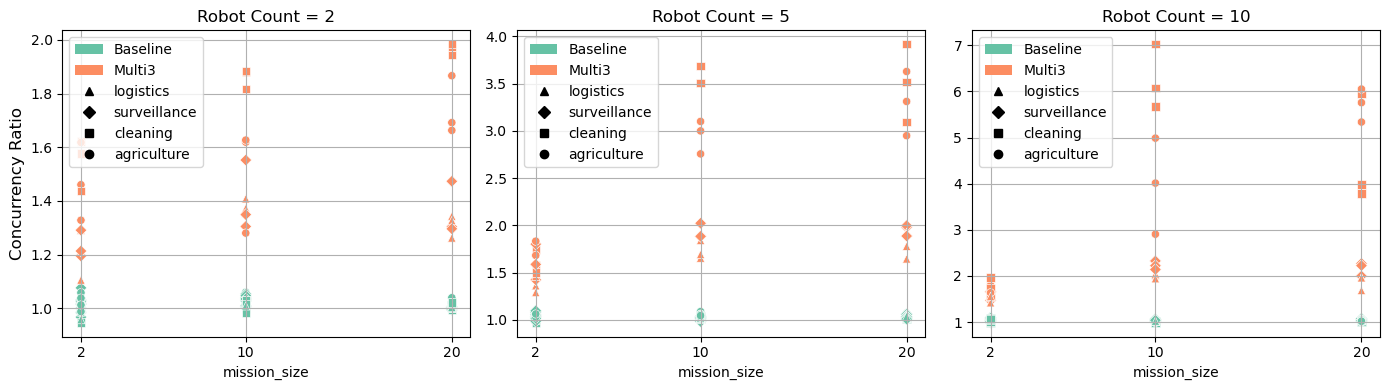

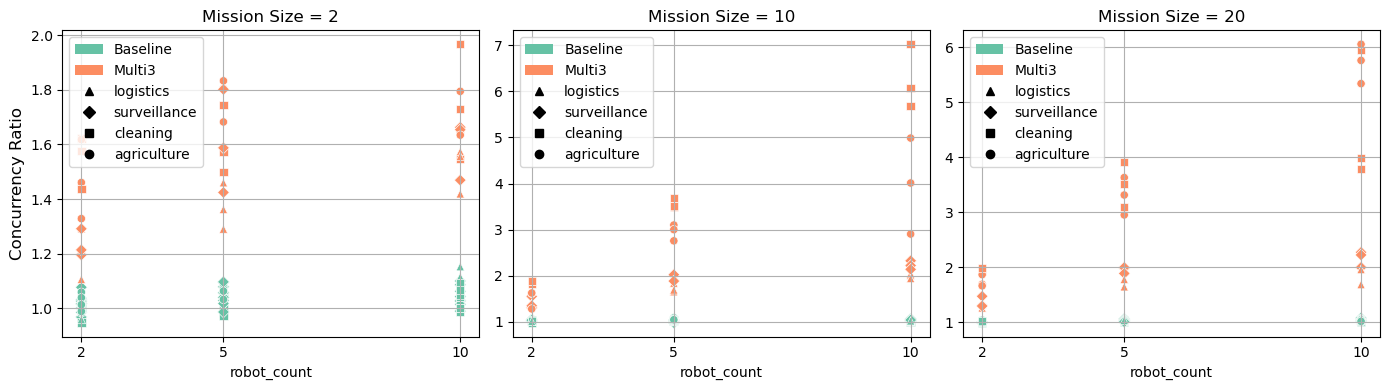

In [43]:
multiplot(concurrency_ratio_df, "../output/images/cr_by_mission_size_scatter.pdf", "robot_count", "mission_size","CR","Robot Count = $field$", "Mission Size", "Concurrency Ratio")
multiplot(concurrency_ratio_df, "../output/images/cr_by_robot_count_scatter.pdf", "mission_size", "robot_count","CR","Mission Size = $field$", "Robot Count", "Concurrency Ratio")

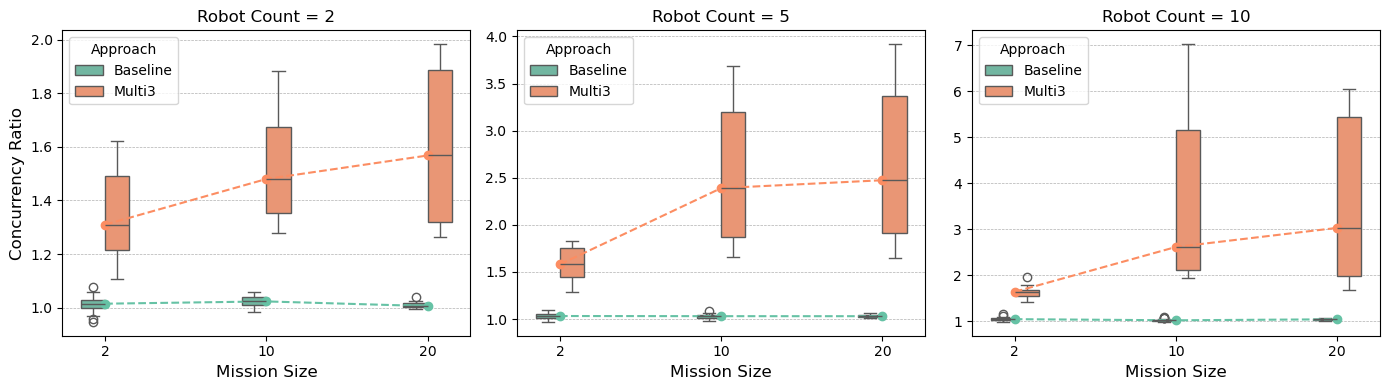

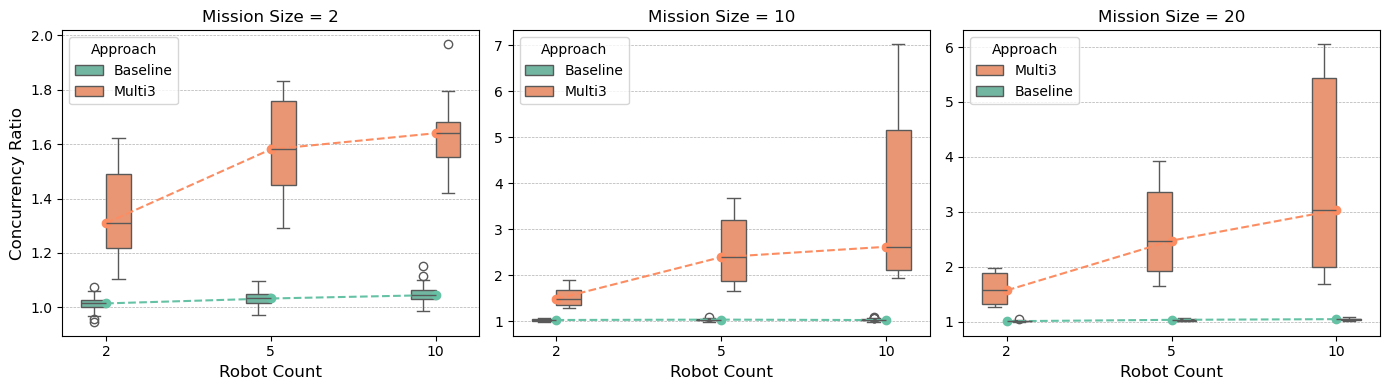

In [44]:
multi_box_plot(concurrency_ratio_df, "../output/images/cr_by_mission_size_box.pdf", "robot_count", "mission_size", "CR", "Robot Count", "Mission Size", "Concurrency Ratio")
multi_box_plot(concurrency_ratio_df, "../output/images/cr_by_robot_count_box.pdf", "mission_size", "robot_count", "CR", "Mission Size", "Robot Count", "Concurrency Ratio")

In [45]:
group_cols = ["scenario", "robot_count", "mission_size", "inventory_id"]

df_concurrency_baseline = concurrency_ratio_df[concurrency_ratio_df["mode"].isin(["bl0", "bl1", "bl2"])]

df_concurrency_baseline_avg = (
    df_concurrency_baseline
    .groupby(group_cols, as_index=False)
    .agg({
        "mission_duration": "mean",
        "total_active_time": "mean",
        "CR": "mean"
    })
)

df_concurrency_baseline_avg["mode"] = "baseline"

df_concurrency_multi3 = concurrency_ratio_df[concurrency_ratio_df["mode"] == "multi3"].copy()

df_concurrency_grouped = pd.concat([df_concurrency_baseline_avg, df_concurrency_multi3], ignore_index=True)

df_concurrency_grouped = df_concurrency_grouped[group_cols + ["mode", "mission_duration", "total_active_time", "CR"]]
df_concurrency_grouped

,scenario,robot_count,mission_size,inventory_id,mode,mission_duration,total_active_time,CR
0,agriculture,2,2,0,baseline,111.004905,111.033373,1.000318
1,agriculture,2,2,1,baseline,121.005003,122.549968,1.012978
2,agriculture,2,2,2,baseline,102.004999,105.537053,1.034488
3,agriculture,2,10,0,baseline,470.502052,493.204109,1.048115
4,agriculture,2,10,1,baseline,453.005083,461.706922,1.019202
...,...,...,...,...,...,...,...,...
211,surveillance,5,2,2,multi3,69.022469,109.576287,1.587545
212,surveillance,2,2,0,multi3,91.502127,111.035802,1.213478
213,cleaning,10,10,0,multi3,91.502101,519.374768,5.676097
214,logistics,5,20,2,multi3,703.502310,1251.794922,1.779376


In [46]:
pivot_concurrency_df = df_concurrency_grouped.pivot_table(
    index=["scenario", "robot_count", "mission_size", "inventory_id"],
    columns="mode",
    values=["CR"]
)

pivot_concurrency_df.columns = [f"{metric}_{mode}" for metric, mode in pivot_concurrency_df.columns]

pivot_concurrency_df = pivot_concurrency_df.reset_index()

pivot_concurrency_df["CR_diff_percentage"] = (
    (pivot_concurrency_df["CR_multi3"] - pivot_concurrency_df["CR_baseline"])
    / pivot_concurrency_df["CR_baseline"]
) * 100

ordered_cols = [
    "scenario",
    "robot_count",
    "mission_size",
    "inventory_id",
    "CR_baseline",
    "CR_multi3",
    "CR_diff_percentage"
]

pivot_concurrency_df = pivot_concurrency_df[ordered_cols]

pivot_concurrency_df

,scenario,robot_count,mission_size,inventory_id,CR_baseline,CR_multi3,CR_diff_percentage
0,agriculture,2,2,0,1.000318,1.617968,61.745350
1,agriculture,2,2,1,1.012978,1.460444,44.173423
2,agriculture,2,2,2,1.034488,1.328127,28.384882
3,agriculture,2,10,0,1.048115,1.280281,22.150864
4,agriculture,2,10,1,1.019202,1.618843,58.834347
...,...,...,...,...,...,...,...
103,surveillance,10,10,1,1.045862,2.139138,104.533476
104,surveillance,10,10,2,1.048599,2.325021,121.726371
105,surveillance,10,20,0,1.026052,2.271618,121.394035
106,surveillance,10,20,1,1.073218,1.998494,86.215108


#### Computing averages per configuration

In [47]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["mission_size", "robot_count"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["mission_size", "robot_count", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,mission_size,robot_count,CR_baseline,CR_multi3,CR_diff_percentage
0,2,2,1.011709,1.362897,34.827989
1,2,5,1.032827,1.588678,53.701786
2,2,10,1.046775,1.637836,56.528223
3,10,2,1.025142,1.537362,50.261502
4,10,5,1.029962,2.545294,146.667304
5,10,10,1.025298,3.613584,254.680063
6,20,2,1.009119,1.593786,57.944483
7,20,5,1.032527,2.636629,155.537290
8,20,10,1.037822,3.579661,246.389017


In [48]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["robot_count"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["robot_count", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,robot_count,CR_baseline,CR_multi3,CR_diff_percentage
0,2,1.015323,1.498015,47.677991
1,5,1.031772,2.256867,118.635460
2,10,1.036632,2.943694,185.865768


In [49]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["mission_size"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

concurrency_average_df.columns = ["mission_size", "CR_baseline", "CR_multi3", "CR_diff_percentage"]

concurrency_average_df

,mission_size,CR_baseline,CR_multi3,CR_diff_percentage
0,2,1.030437,1.529803,48.352666
1,10,1.026801,2.565413,150.536290
2,20,1.026489,2.603359,153.290263


In [50]:
concurrency_average_df = (
    pivot_concurrency_df.groupby(["scenario"])
      .agg({
          "CR_baseline": "mean",
          "CR_multi3": "mean",
          "CR_diff_percentage": "mean"
      })
    .reset_index()
)

workload_average_df.rename(columns={"CR_diff_percentage": "average_of_CR_diff_percentage"}, inplace=True)


concurrency_average_df.columns = ["scenario", "CR_baseline", "CR_multi3", "average_of_CR_diff_percentage"]

concurrency_average_df

,scenario,CR_baseline,CR_multi3,average_of_CR_diff_percentage
0,agriculture,1.033271,2.679579,159.230037
1,cleaning,1.016213,2.959014,191.260836
2,logistics,1.031746,1.573580,52.392163
3,surveillance,1.030406,1.719261,66.689256


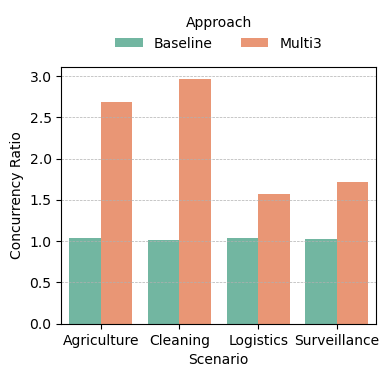

In [51]:
melted = concurrency_average_df.melt(id_vars='scenario', value_vars=['CR_baseline', 'CR_multi3'], var_name='mode', value_name='CR')

melted['mode'] = melted['mode'].replace({'CR_baseline': 'Baseline', 'CR_multi3': 'Multi3'})

melted['scenario'] = melted['scenario'].str.capitalize()

plt.figure(figsize=(4, 4))
sns.barplot(data=melted, x='scenario', y='CR', hue='mode', palette=approach_colors)

plt.xlabel('Scenario')
plt.ylabel('Concurrency Ratio')

plt.legend(
    title='Approach',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False
)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("../output/images/cr_scenario_summary.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Global summary of metrics

In [52]:
summary_df = (
    df_completion_average[
        [
            "scenario",
            "makespan_baseline",
            "makespan_multi3",
            "average_of_makespan_diff_percentage",
        ]
    ]
    .merge(
        idle_times_average_df[
            [
                "scenario",
                "average_robot_idle_time_baseline",
                "average_robot_idle_time_multi3",
                "average_of_average_robot_idle_time_diff_percentage",
                "idle_ratio_baseline",
                "idle_ratio_multi3",
                "average_of_idle_ratio_diff_percentage",
            ]
        ],
        on="scenario",
        how="left",
    )
    .merge(
        workload_average_df[
            [
                "scenario",
                "workload_var_baseline",
                "workload_var_multi3",
                "average_of_workload_var_diff_percentage",
                "workload_cv_baseline",
                "workload_cv_multi3",
                "average_of_workload_cv_diff_percentage",
            ]
        ],
        on="scenario",
        how="left",
    )
    .merge(
        concurrency_average_df[
            [
                "scenario",
                "CR_baseline",
                "CR_multi3",
                "average_of_CR_diff_percentage"
            ]
        ],
        on="scenario",
        how="left",
    )
)

order = ["cleaning", "agriculture", "surveillance", "logistics"]
summary_df = summary_df.set_index("scenario").loc[order].reset_index()

summary_df

,scenario,makespan_baseline,makespan_multi3,average_of_makespan_diff_percentage,average_robot_idle_time_baseline,average_robot_idle_time_multi3,average_of_average_robot_idle_time_diff_percentage,idle_ratio_baseline,idle_ratio_multi3,average_of_idle_ratio_diff_percentage,workload_var_baseline,workload_var_multi3,average_of_workload_var_diff_percentage,workload_cv_baseline,workload_cv_multi3,average_of_workload_cv_diff_percentage,CR_baseline,CR_multi3,average_of_CR_diff_percentage
0,cleaning,499.901373,193.013468,-53.546305,365.270924,42.916769,-78.203926,0.729850,0.368882,-53.764716,22096.881225,846.651474,-67.359221,1.097216,0.372464,-58.653265,1.016213,2.959014,191.260836
1,agriculture,478.625116,225.787798,-45.414503,347.006624,73.567213,-67.839689,0.725928,0.433213,-42.714701,21088.092065,1458.764365,-58.623094,1.033696,0.375568,-53.424217,1.033271,2.679579,159.230037
2,surveillance,463.438402,318.512838,-28.511101,338.581053,171.289706,-44.169784,0.727169,0.589589,-20.905018,23401.079766,4688.150690,-24.574337,1.043015,0.603765,-30.543591,1.030406,1.719261,66.689256
3,logistics,583.124137,420.622763,-24.233532,425.707010,240.690738,-37.852697,0.726789,0.615316,-17.316574,24700.599763,7637.910530,-20.873206,0.910371,0.578809,-30.528639,1.031746,1.573580,52.392163
